In [5]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


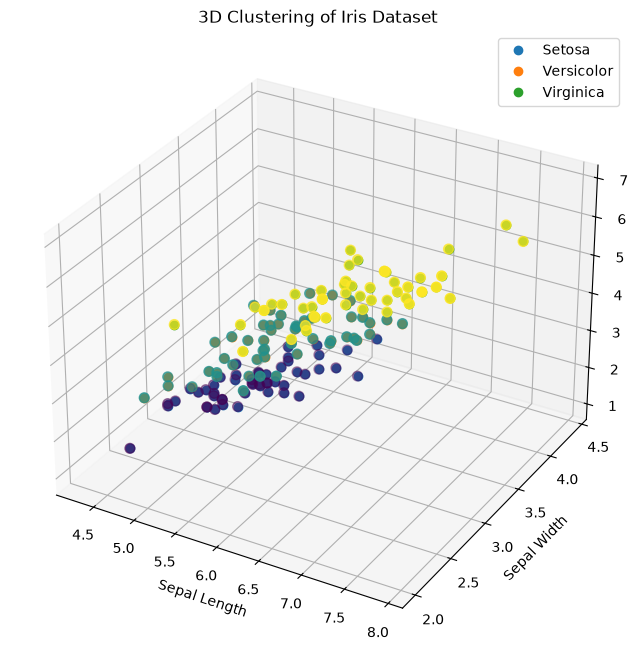

In [9]:
def plot_3d_clusters(X, labels):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='viridis', s=50)
    ax.set_xlabel('Sepal Length')
    ax.set_ylabel('Sepal Width')
    ax.set_zlabel('Petal Length')
    str_labels = ['Setosa', 'Versicolor', 'Virginica']
    list(map(lambda x: ax.plot3D(X[labels == x, 0], X[labels == x, 1], X[labels == x, 2], 'o', label=str_labels[x]), np.unique(labels)))
    plt.title('3D Clustering of Iris Dataset')
    plt.legend()
    plt.show()
plot_3d_clusters(df.values, y)

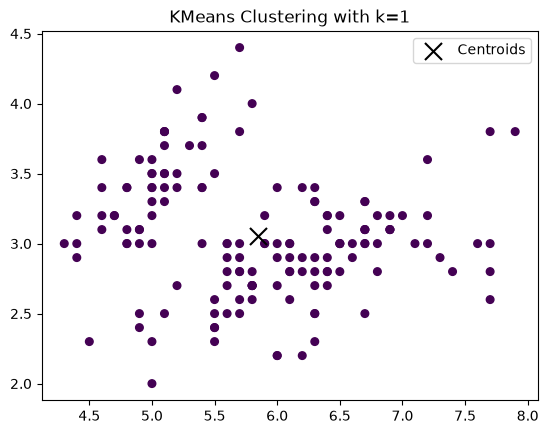

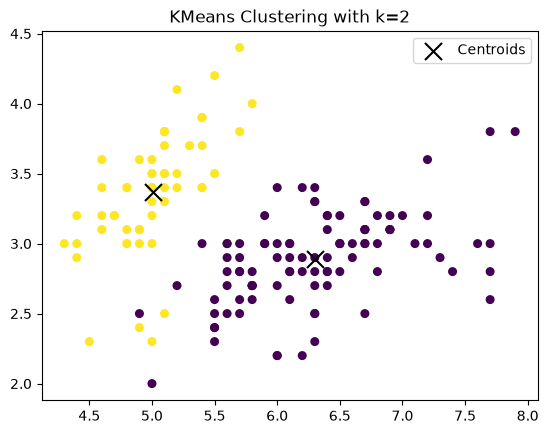

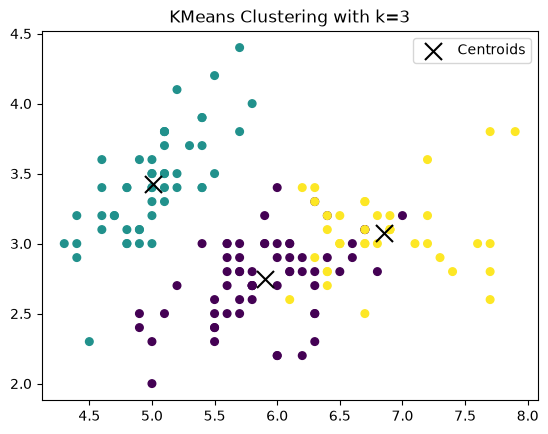

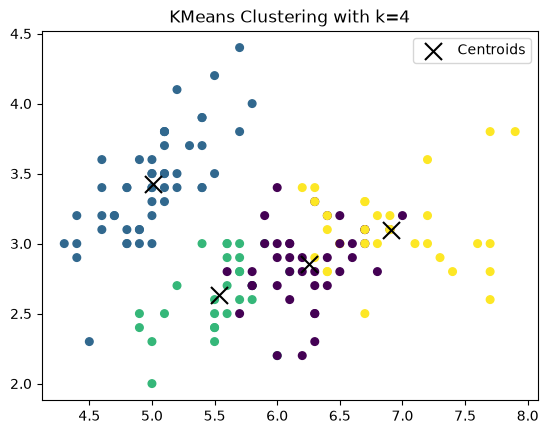

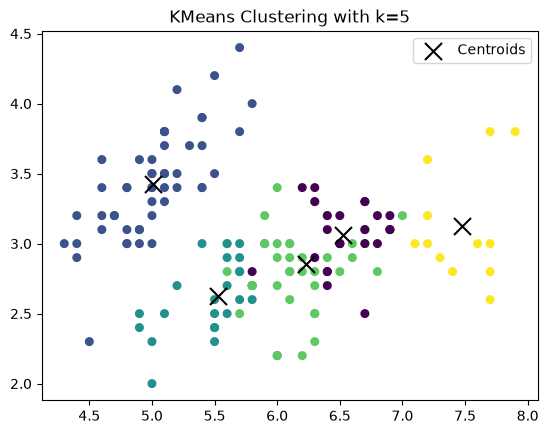

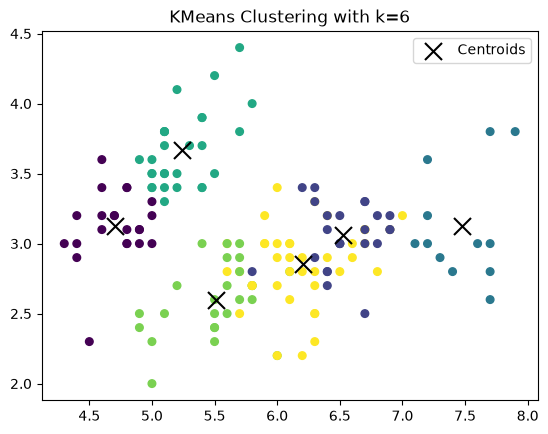

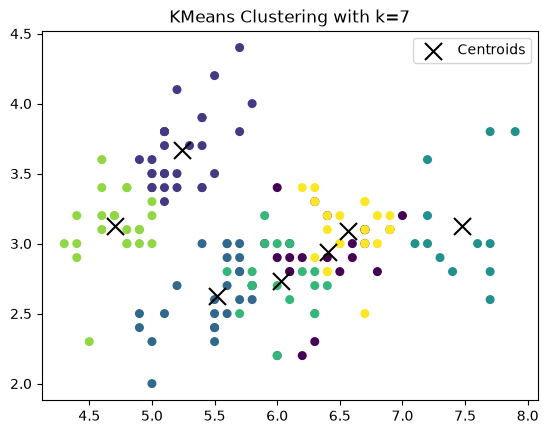

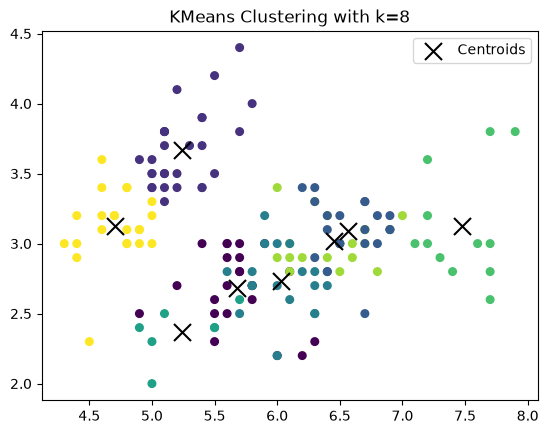

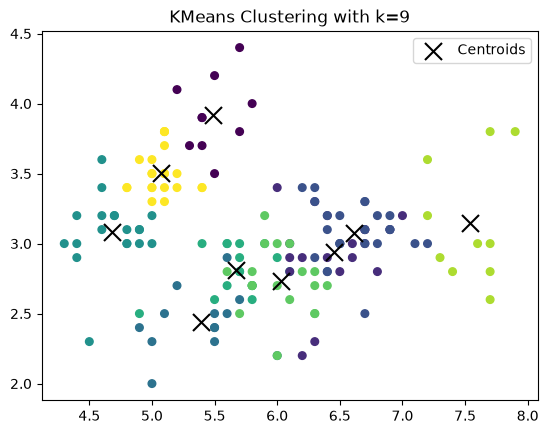

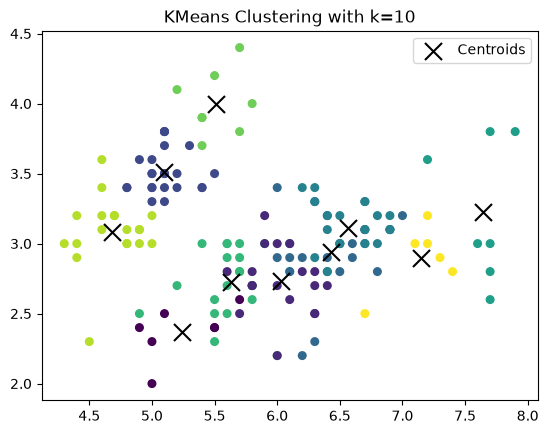

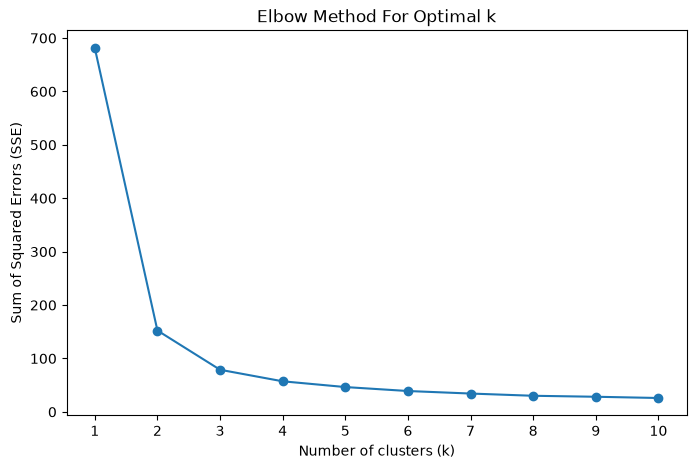

In [19]:
def kmeans_clustering(X, n_clusters):
    """Unsupervised KMeans clustering on the dataset.
    Args:
        X (array-like): Feature data.
        y (array-like): True labels for evaluation.
        n_clusters (int): Number of clusters to form.
    """
    # Sum of Squared Errors (SSE) for different values of k to make the elbow plot
    sse = []
    for k in range(1, n_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        y_kmeans = kmeans.fit_predict(X)
        sse.append(kmeans.inertia_)

        plt.figure()
        plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=30)
        plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    c='k', marker='x', s=150, label='Centroids')
        plt.title(f'KMeans Clustering with k={k}')
        plt.legend()
        plt.show()
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, n_clusters + 1), sse, marker='o')
    plt.title('Elbow Method For Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.xticks(range(1, n_clusters + 1))
    plt.show()
kmeans_clustering(df.values, 10)